In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline

In [10]:
x = 6*np.random.rand(200,1)-3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200,1)

#here the equation is y = 0.8x^2 + 0.9x + 2

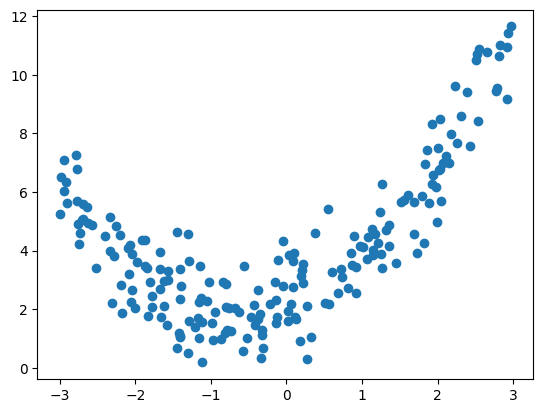

In [11]:
plt.scatter(x,y)
plt.show()

In [12]:
lr = LinearRegression()

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [15]:
scaler = StandardScaler()

In [16]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [17]:
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [18]:
y_pred = lr.predict(x_test_scaled)

In [19]:
r2_score(y_test, y_pred)

0.4242779888459105

Now applying the polynomial feaure

In [20]:
plreg = PolynomialFeatures(degree = 2, include_bias=False)

x_train_trans = plreg.fit_transform(x_train)
x_test_trans = plreg.transform(x_test)

In [21]:
lr.fit(x_train_trans, y_train)

LinearRegression()

In [22]:
y_pred2 = lr.predict(x_test_trans)

In [23]:
r2_score(y_test, y_pred2)

0.8731672792218482

In [28]:
print(x_train[0])
print(x_train_trans[0])

[0.73035799]
[0.73035799 0.5334228 ]


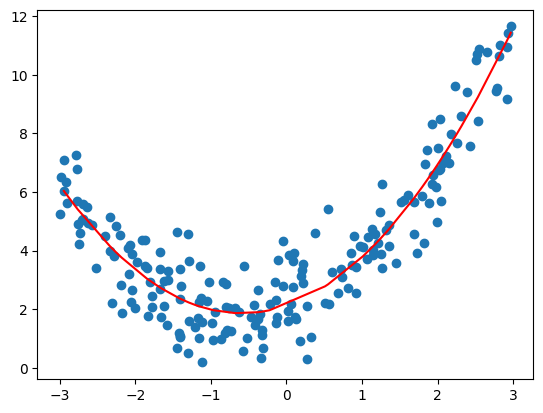

In [27]:
plt.scatter(x,y)

# Sort the x_test values before plotting to ensure a smooth line
sort_idx = np.argsort(x_test.flatten())
plt.plot(x_test[sort_idx], y_pred2[sort_idx], color = 'red')
plt.show()

# Multi-polynomial regression

In [30]:
import plotly.express as px

In [48]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

In [49]:
df = pd.DataFrame(np.hstack((x,y,z)), columns = ['x', 'y', 'z'])
fig = px.scatter_3d(df, x = 'x', y = 'y', z = 'z')
fig.show()

In [56]:
X = np.hstack((x, y))
Z = z
X_train, X_test, Z_train, Z_test = train_test_split(X, Z, test_size = 0.2, random_state = 42)

In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
plreg = PolynomialFeatures(degree = 4, include_bias=False)

X_train_trans = plreg.fit_transform(X_train_scaled)
X_test_trans = plreg.transform(X_test_scaled)

In [59]:
lr.fit(X_train_trans, Z_train)

LinearRegression()

In [60]:
Z_pred = lr.predict(X_test_trans)

In [61]:
r2_score(Z_test, Z_pred)

0.9768344110478081